<a href="https://colab.research.google.com/github/tharun2128/DEEP-LEARNING/blob/main/EX_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Roll No : 24BAD126 | Seed : 4126
Features : (20640, 8)  Target : (20640,)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.2743 - mae: 0.7206 - val_loss: 0.4729 - val_mae: 0.5011
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4437 - mae: 0.4769 - val_loss: 0.3964 - val_mae: 0.4630
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3965 - mae: 0.4492 - val_loss: 0.3764 - val_mae: 0.4491
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3798 - mae: 0.4351 - val_loss: 0.3681 - val_mae: 0.4409
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3756 - mae: 0.4261 - val_loss: 0.3627 - val_mae: 0.4330
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3699 - mae: 0.4179 - val_loss: 0.3540 - val_mae: 0.4252
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3589 - mae: 0.4105 - val_loss: 0.3440 - val_mae: 0.4195
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3459 - mae: 0.4036 - val_loss: 0.3339 - val_mae: 0.4130
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

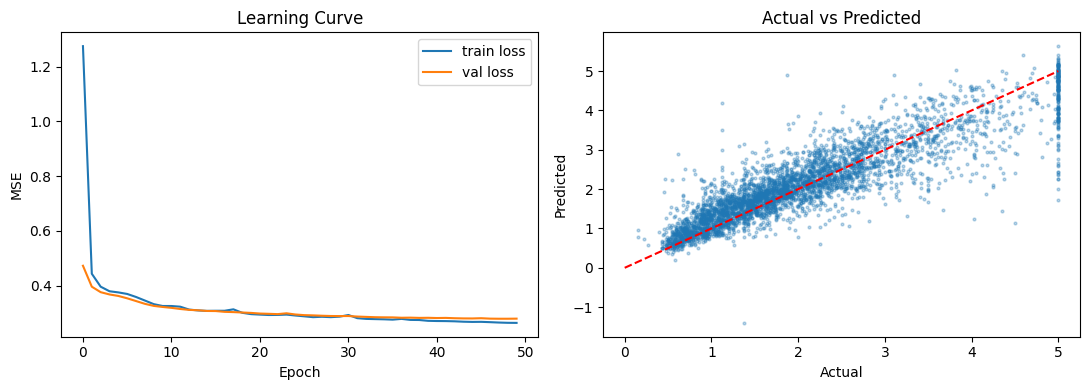

In [3]:
# =============================================================
# EXPT 1 - TASK A : ANN FOR REGRESSION (California Housing)
# NAME    : Tharun
# ROLL NO : 24BAD126
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- Roll number used as the random seed (reproducible results) ----
ROLL_NO = "24BAD126"
SEED = int("".join(c for c in ROLL_NO if c.isdigit())) % 10000
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Roll No :", ROLL_NO, "| Seed :", SEED)

# ---- Step 2 : Load dataset ----
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target                            # median house value (in $100,000)
print("Features :", X.shape, " Target :", y.shape)
print(X.head())

# ---- Step 3 : Train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED)

# ---- Step 4 : Feature scaling ----
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

# ---- Step 5 : Build ANN ----
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1,  activation='linear')          # linear output for regression
])
model.summary()

# ---- Step 6 : Compile ----
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ---- Step 7 : Train ----
history = model.fit(X_train, y_train, validation_split=0.2,
                    epochs=50, batch_size=32, verbose=1)

# ---- Step 8 : Predict ----
y_pred = model.predict(X_test).flatten()

# ---- Step 9 : Evaluate ----
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("\n----- REGRESSION RESULTS (Roll No %s) -----" % ROLL_NO)
print("MSE  : %.4f" % mse)
print("MAE  : %.4f" % mae)
print("RMSE : %.4f" % rmse)
print("R2   : %.4f" % r2_score(y_test, y_pred))

# ---- Plots ----
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Learning Curve'); plt.legend()
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred, s=4, alpha=0.3)
plt.plot([0,5],[0,5],'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.tight_layout(); plt.show()

Roll No : 24BAD126 | Seed : 4126
Shape : (569, 30)  Classes : ['malignant' 'benign']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7115 - loss: 0.5916 - val_accuracy: 0.8901 - val_loss: 0.4484
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9038 - loss: 0.3678 - val_accuracy: 0.9121 - val_loss: 0.2909
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9231 - loss: 0.2544 - val_accuracy: 0.9341 - val_loss: 0.2061
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9423 - loss: 0.1881 - val_accuracy: 0.9451 - val_loss: 0.1539
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9670 - loss: 0.1466 - val_accuracy: 0.9451 - val_loss: 0.1211
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1203 - val_accuracy: 0.9560 - val_loss: 0.0998
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9725 - loss: 0.1026 - val_accuracy: 0.9780 - val_loss: 0.0850
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.0899 - val_accuracy: 0.9780 - val_loss

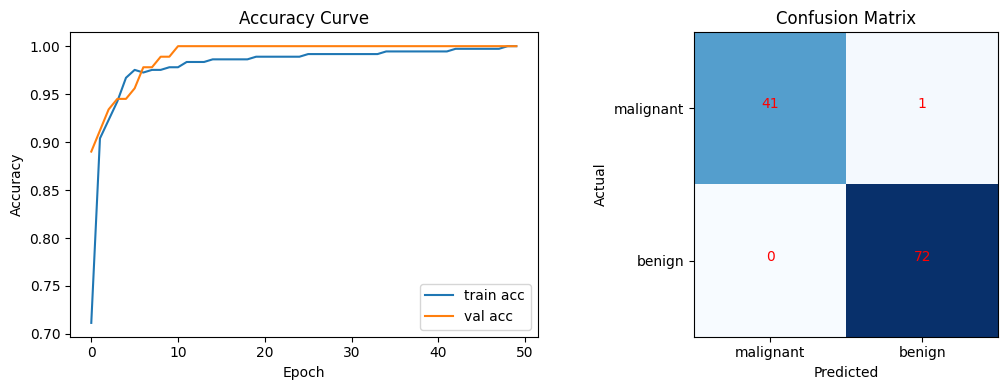

In [4]:
# =============================================================
# EXPT 1 - TASK B : ANN FOR CLASSIFICATION (Breast Cancer)
# NAME    : Tharun
# ROLL NO : 24BAD126
# =============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

ROLL_NO = "24BAD126"
SEED = int("".join(c for c in ROLL_NO if c.isdigit())) % 10000
np.random.seed(SEED); tf.random.set_seed(SEED)
print("Roll No :", ROLL_NO, "| Seed :", SEED)

# ---- Step 2 : Load dataset ----
data = load_breast_cancer()
X, y = data.data, data.target              # 0 = malignant, 1 = benign
print("Shape :", X.shape, " Classes :", data.target_names)

# ---- Step 3 : Split ----
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y)

# ---- Step 4 : Feature scaling ----
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

# ---- Step 5 : Design ANN ----
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')        # sigmoid -> probability
])
model.summary()

# ---- Step 6 : Compile ----
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ---- Step 7 : Train ----
history = model.fit(X_train, y_train, validation_split=0.2,
                    epochs=50, batch_size=16, verbose=1)

# ---- Step 8 : Predict ----
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

# ---- Step 9 : Evaluate ----
print("\n----- CLASSIFICATION RESULTS (Roll No %s) -----" % ROLL_NO)
print("Accuracy  : %.4f" % accuracy_score(y_test, y_pred))
print("Precision : %.4f" % precision_score(y_test, y_pred))
print("Recall    : %.4f" % recall_score(y_test, y_pred))
print("F1-score  : %.4f" % f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, y_pred, target_names=data.target_names))

# ---- Plots ----
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curve'); plt.legend()
plt.subplot(1,2,2)
plt.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', color='red')
plt.xticks([0,1], data.target_names); plt.yticks([0,1], data.target_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.tight_layout(); plt.show()